In [4]:
import numpy as np
import pandas as pd

In [7]:
df = pd.DataFrame({'col_1':[5, 6, np.nan, 3, 7],
                     'col_2':[27, 6, 7, 40, 70],
                     'col_3':[1, 45, 6, 62, 7]},
                   index = ['row_1', 'row_2', 'row_3', 'row_4', 'row_5']
                   )
df

,col_1,col_2,col_3
row_1,5.0,27,1
row_2,6.0,6,45
row_3,NaN,7,6
row_4,3.0,40,62
row_5,7.0,70,7


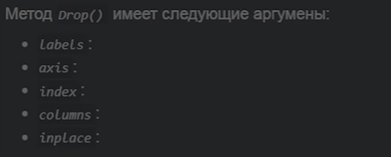

In [10]:
df.drop('row_2')

,col_1,col_2,col_3
row_1,5.0,27,1
row_3,NaN,7,6
row_4,3.0,40,62
row_5,7.0,70,7


In [13]:
df.drop('col_1', axis = 1)

,col_2,col_3
row_1,27,1
row_2,6,45
row_3,7,6
row_4,40,62
row_5,70,7


In [15]:
df.drop(['col_1', 'col_2'], axis = 1)

,col_3
row_1,1
row_2,45
row_3,6
row_4,62
row_5,7


In [21]:
df.drop(index='row_3', columns='col_3')

,col_1,col_2
row_1,5.0,27
row_2,6.0,6
row_4,3.0,40
row_5,7.0,70


## Метод astype()

In [24]:
category_list = ['a', 'b', 'c', 'd', 'e']

df = pd.DataFrame({'col_1': [i for i in range(1000)],
                   'col_2': [float(i) for i in range(1000)],
                   'col_3': [category_list[i%5] for i in range(1000)],
                   'col_4': [*pd.date_range(start='01-01-2000', periods=1000).strftime('%m-%d-%y')]},
                  index = [f'row_{i}' for i in range(1000)]
                 )

df

,col_1,col_2,col_3,col_4
row_0,0,0.0,a,01-01-00
row_1,1,1.0,b,01-02-00
row_2,2,2.0,c,01-03-00
row_3,3,3.0,d,01-04-00
row_4,4,4.0,e,01-05-00
...,...,...,...,...
row_995,995,995.0,a,09-22-02
row_996,996,996.0,b,09-23-02
row_997,997,997.0,c,09-24-02
row_998,998,998.0,d,09-25-02


In [26]:
df.dtypes

col_1      int64
col_2    float64
col_3     object
col_4     object
dtype: object

In [28]:
new_df = df.astype({'col_1': np.int8})

In [30]:
new_df

,col_1,col_2,col_3,col_4
row_0,0,0.0,a,01-01-00
row_1,1,1.0,b,01-02-00
row_2,2,2.0,c,01-03-00
row_3,3,3.0,d,01-04-00
row_4,4,4.0,e,01-05-00
...,...,...,...,...
row_995,-29,995.0,a,09-22-02
row_996,-28,996.0,b,09-23-02
row_997,-27,997.0,c,09-24-02
row_998,-26,998.0,d,09-25-02


In [32]:
new_df = df.astype({'col_3':'category'})

In [34]:
new_df.memory_usage()

Index    8000
col_1    8000
col_2    8000
col_3    1212
col_4    8000
dtype: int64

In [40]:
df = df.astype({'col_1': np.int16,
                'col_2': np.float16,
                'col_3': 'category',
                'col_4': 'datetime64[ns]'}
              )
df.reset_index(drop=True, inplace=True)

In [42]:
df

,col_1,col_2,col_3,col_4
0,0,0.0,a,2000-01-01
1,1,1.0,b,2000-01-02
2,2,2.0,c,2000-01-03
3,3,3.0,d,2000-01-04
4,4,4.0,e,2000-01-05
...,...,...,...,...
995,995,995.0,a,2002-09-22
996,996,996.0,b,2002-09-23
997,997,997.0,c,2002-09-24
998,998,998.0,d,2002-09-25


In [46]:
print(df.dtypes, end='\n\n')
print(df.memory_usage())

col_1             int16
col_2           float16
col_3          category
col_4    datetime64[ns]
dtype: object

Index     132
col_1    2000
col_2    2000
col_3    1212
col_4    8000
dtype: int64
